In [72]:
import pandas as pd
import numpy as np
from fitter import Fitter
import matplotlib.pyplot as plt
import yfinance as yf

## Descripción de los origenes de datos 

Para este reporte, se utilizó las descargas con la librería de *yfinance* para obtener los datos de los cierres de cada día por los útlimos 12 días, para posteriormente agruparlos por semana para hacer el análisis para las distribuciones. 

A continuación una breve descripcipción de los índices a analizar: 
- *S&P 500*: mide el desempeño de aproximadamente 500 de las empresas más grandes de Estados Unidos. 
- El *Dow Jones Industrial Average (DJI)*: sigue a 30 grandes empresas industriales y tradicionales, reflejando el comportamiento de compañías consolidadas de distintos sectores.
- Nasdaq 100: agrupa a 100 de las principales empresas no financieras que cotizan en el Nasdaq, con una fuerte concentración en tecnología.
- S&P/BMV IPC: principal índice de la Bolsa Mexicana de Valores y mide el desempeño de las empresas más importantes de México.

## Descargas

In [73]:
# SP500
sp500 = yf.download("^GSPC", interval="1d", start="2025-03-24", end="2026-03-24")
sp500.to_csv("sp500_data.csv")

# DOW JONES
dow = yf.download("^DJI", interval="1d", start="2025-03-24", end="2026-03-24")
dow.to_csv("dowjones_data.csv")

# NASDAQ 100
nasdaq100 = yf.download("^NDX", interval="1d", start="2025-03-24", end="2026-03-24")
nasdaq100.to_csv("nasdaq100_data.csv")

# S&P/BMV IPC (México)
ipc = yf.download("^MXX", interval="1d", start="2025-03-24", end="2026-03-24")
ipc.to_csv("ipc_mexico_data.csv")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Carga de información

In [74]:
def load_data(file): # Se cargan las descargas y limpieza de columnas
    df = pd.read_csv(file, header=2)
    df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]

    print(df.columns)

    df["Date"] = pd.to_datetime(df["Date"])
    df["Close"] = pd.to_numeric(df["Close"])

    df = df.sort_values("Date")
    print(df.columns)

    return df

## Procesamiento 

In [75]:
def process_data(df): # Procesar si es que el día cerro en alza en comparación al día anterior
    df["prev_close"] = df["Close"].shift(1)
    df["bullish"] = (df["Close"] > df["prev_close"]).astype(int)

    df = df.dropna(subset=["prev_close"])

    df["week"] = df["Date"].dt.to_period("W")
    weekly_bullish_counts = df.groupby("week")["bullish"].sum() # Agrupar los días por semana para la distribución
    
    print(weekly_bullish_counts)
    return weekly_bullish_counts

## Histograma

In [76]:
def plot_histogram(weekly_bullish_counts, title): # Se generan los histogramas de distribución por días en alza
    plt.figure(figsize=(8,5))

    plt.hist(weekly_bullish_counts.values, bins=range(0,7), edgecolor='black')

    plt.title(title)
    plt.xlabel("Número de días en alza en la semana")
    plt.ylabel("Frecuencia (número de semanas)")

    plt.xticks(range(0,7))
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

## Ajuste de distribución

In [77]:
def fit_distribution(weekly_bullish_counts, title): # Se aplica la librería Fitter
    f = Fitter(weekly_bullish_counts.values)
    f.fit()

    best = f.get_best(method='sumsquare_error')
    best_name = list(best.keys())[0]

    print("\nMejor distribución:", best_name)
    print("Paramétros:", best[best_name])

    # Plot summary with title
    plt.figure(figsize=(8,5))
    f.summary()

    plt.title(f"{title} \Mejor distribución: {best_name}")
    plt.xlabel("Número de días en alza en la semana")
    plt.ylabel("Frecuencia (número de semanas)")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return f

In [78]:
def compare_indices(dict_of_series): # Se genera la matriz de correlación entre índices 
    df = pd.DataFrame(dict_of_series)
    corr = df.corr()

    print("\Matriz de correlación:")
    print(corr)

    return corr

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
week
2025-03-24/2025-03-30    1
2025-03-31/2025-04-06    3
2025-04-07/2025-04-13    2
2025-04-14/2025-04-20    2
2025-04-21/2025-04-27    4
2025-04-28/2025-05-04    5
2025-05-05/2025-05-11    2
2025-05-12/2025-05-18    5
2025-05-19/2025-05-25    1
2025-05-26/2025-06-01    2
2025-06-02/2025-06-08    4
2025-06-09/2025-06-15    3
2025-06-16/2025-06-22    1
2025-06-23/2025-06-29    4
2025-06-30/2025-07-06    3
2025-07-07/2025-07-13 

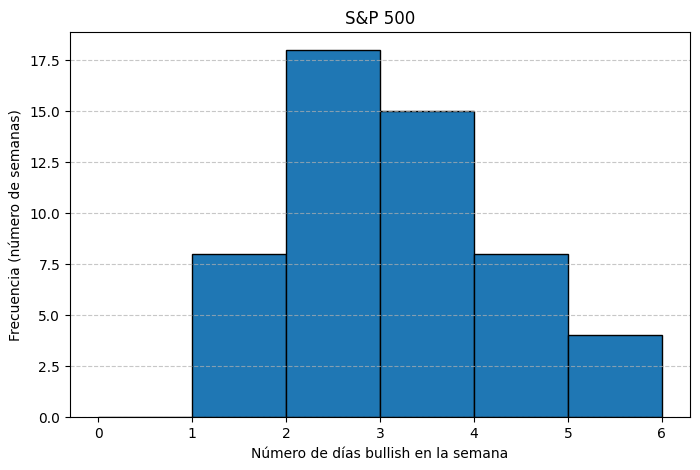

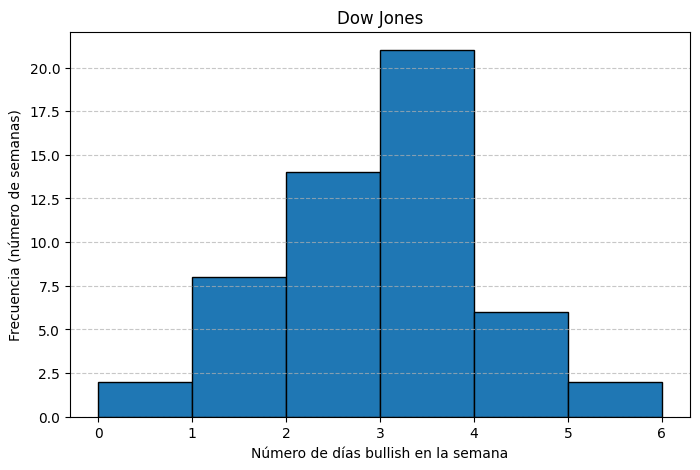

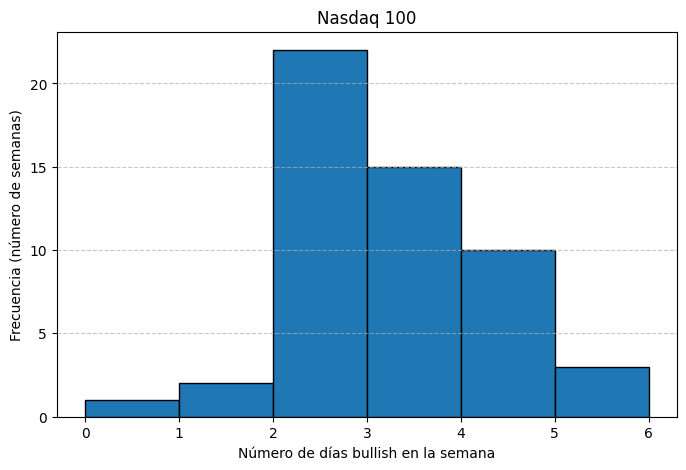

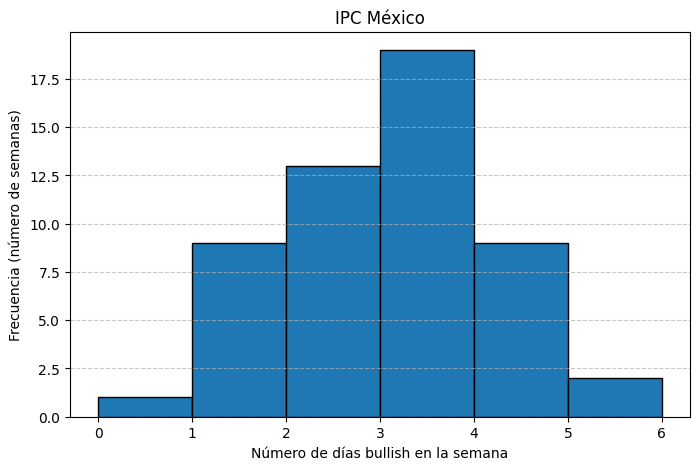

2026-03-30 07:42:50.847 | WARNING  | fitter.fitter:_fit_single_distribution:422 - SKIPPED _fit: TypeError (timeout=30s or fitting failed)
2026-03-30 07:42:50.854 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted anglit: error=148.148970, AIC=163.71, KS=0.2323
2026-03-30 07:42:50.906 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted cauchy: error=148.729876, AIC=190.55, KS=0.2053
2026-03-30 07:42:50.922 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted beta: error=145.501304, AIC=3.81, KS=0.3399
2026-03-30 07:42:50.925 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted argus: error=148.792348, AIC=172.19, KS=0.2980
2026-03-30 07:42:50.929 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted chi2: error=145.148764, AIC=-20.71, KS=0.4004
2026-03-30 07:42:50.932 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted chi: error=146.201830, AIC=39.94, KS=0.2868
2026-03-30 07:42:50.933 | INFO     | fitter.fitter:


Best distribution: nakagami
Parameters: {'nu': np.float64(0.1181594159958825), 'loc': np.float64(1.9999999999999998), 'scale': np.float64(0.715498786116471)}


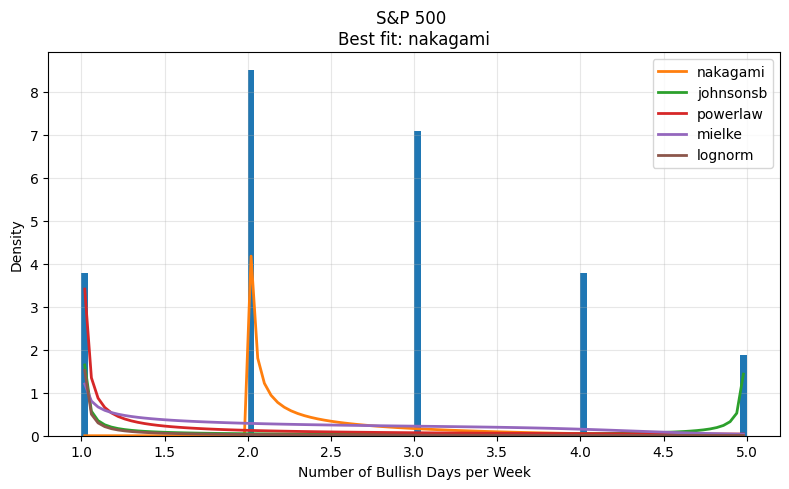

2026-03-30 07:43:21.518 | WARNING  | fitter.fitter:_fit_single_distribution:422 - SKIPPED _fit: TypeError (timeout=30s or fitting failed)
2026-03-30 07:43:21.526 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted anglit: error=101.228709, AIC=167.15, KS=0.2088
2026-03-30 07:43:21.529 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted alpha: error=101.084070, AIC=168.57, KS=0.2276
2026-03-30 07:43:21.529 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted arcsine: error=103.188659, AIC=153.94, KS=0.3161
2026-03-30 07:43:21.531 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted argus: error=101.660960, AIC=174.81, KS=0.3170
2026-03-30 07:43:21.537 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted bradford: error=102.752125, AIC=182.97, KS=0.3369
2026-03-30 07:43:21.539 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted cauchy: error=101.116810, AIC=183.49, KS=0.2351
2026-03-30 07:43:21.541 | INFO     | fi


Best distribution: gennorm
Parameters: {'beta': np.float64(0.3085816498387363), 'loc': np.float64(2.999999999999999), 'scale': np.float64(0.008513403932448732)}


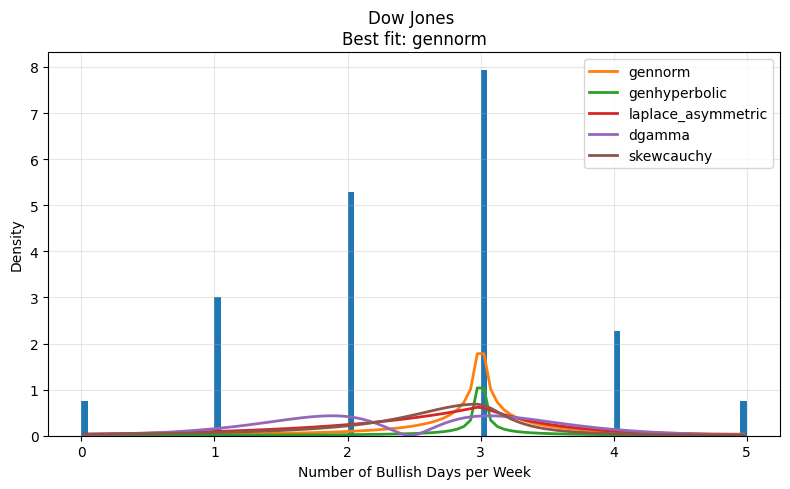

2026-03-30 07:43:51.976 | WARNING  | fitter.fitter:_fit_single_distribution:422 - SKIPPED _fit: TypeError (timeout=30s or fitting failed)
2026-03-30 07:43:51.985 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted anglit: error=112.123775, AIC=163.92, KS=0.2650
2026-03-30 07:43:51.990 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted alpha: error=111.654767, AIC=160.77, KS=0.2293
2026-03-30 07:43:51.991 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted arcsine: error=113.761525, AIC=119.27, KS=0.4172
2026-03-30 07:43:51.994 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted argus: error=112.496699, AIC=168.20, KS=0.2581
2026-03-30 07:43:52.001 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted betaprime: error=111.712740, AIC=162.64, KS=0.2323
2026-03-30 07:43:52.004 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted bradford: error=113.252349, AIC=190.15, KS=0.4154
2026-03-30 07:43:52.006 | INFO     |


Best distribution: genhyperbolic
Parameters: {'p': np.float64(0.3866420707182398), 'a': np.float64(0.0033814857893385494), 'b': np.float64(0.0022478767160822363), 'loc': np.float64(2.002974888721406), 'scale': np.float64(0.0018286149153413324)}


2026-03-30 07:44:22.236 | WARNING  | fitter.fitter:_fit_single_distribution:422 - SKIPPED studentized_range: TimeoutError (timeout=30s or fitting failed)
2026-03-30 07:44:22.342 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted t: error=111.817290, AIC=161.01, KS=0.2367


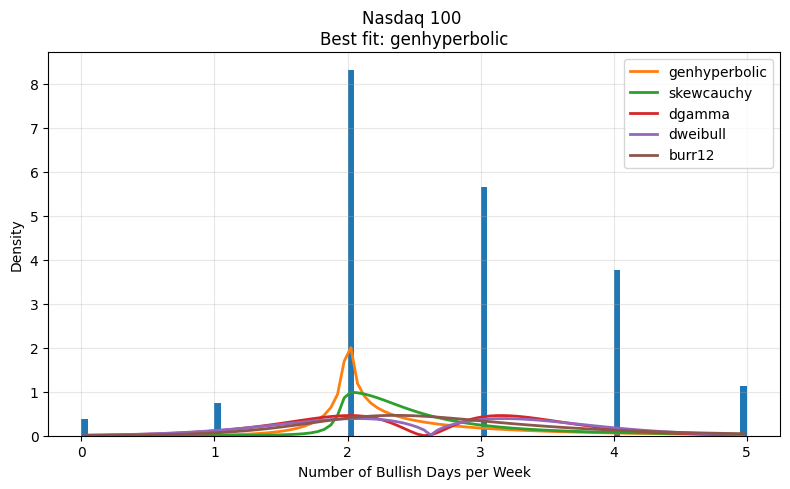

2026-03-30 07:44:22.439 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted arcsine: error=96.326520, AIC=153.35, KS=0.3350
2026-03-30 07:44:22.442 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted alpha: error=94.482823, AIC=169.22, KS=0.2205
2026-03-30 07:44:22.442 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted beta: error=94.381012, AIC=169.30, KS=0.1894
2026-03-30 07:44:22.442 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted argus: error=94.766803, AIC=172.27, KS=0.2763
2026-03-30 07:44:22.448 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted cauchy: error=94.616246, AIC=188.64, KS=0.2084
2026-03-30 07:44:22.452 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted bradford: error=95.255744, AIC=179.71, KS=0.2287
2026-03-30 07:44:22.455 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted cosine: error=94.387853, AIC=165.28, KS=0.1951
2026-03-30 07:44:22.456 | INFO     | fitter.fitte


Best distribution: gennorm
Parameters: {'beta': np.float64(0.3203339047060646), 'loc': np.float64(3.000000000000001), 'scale': np.float64(0.01804373480633091)}


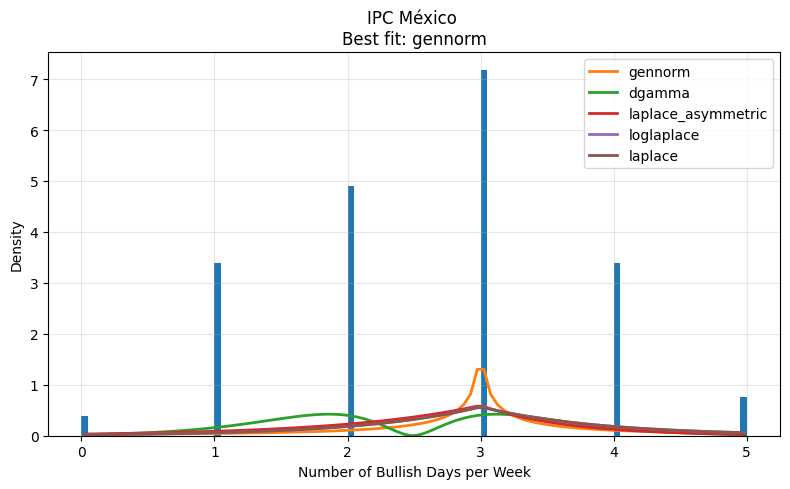


Correlation Matrix:
              SP500       DOW  NASDAQ100       IPC
SP500      1.000000  0.753833   0.791499  0.354753
DOW        0.753833  1.000000   0.628870  0.344128
NASDAQ100  0.791499  0.628870   1.000000  0.529080
IPC        0.354753  0.344128   0.529080  1.000000


,SP500,DOW,NASDAQ100,IPC
SP500,1.000000,0.753833,0.791499,0.354753
DOW,0.753833,1.000000,0.628870,0.344128
NASDAQ100,0.791499,0.628870,1.000000,0.529080
IPC,0.354753,0.344128,0.529080,1.000000


In [79]:
# Cargar cada dataset
sp500 = load_data("sp500_data.csv")
dow = load_data("dowjones_data.csv")
nasdaq = load_data("nasdaq100_data.csv")
ipc = load_data("ipc_mexico_data.csv")

# Procesamiento
sp500_w = process_data(sp500)
dow_w = process_data(dow)
nasdaq_w = process_data(nasdaq)
ipc_w = process_data(ipc)

# Gráfica de histogramas
plot_histogram(sp500_w, "S&P 500")
plot_histogram(dow_w, "Dow Jones")
plot_histogram(nasdaq_w, "Nasdaq 100")
plot_histogram(ipc_w, "IPC México")

# Ajuste de distribución
fit_distribution(sp500_w, "S&P 500")
fit_distribution(dow_w, "Dow Jones")
fit_distribution(nasdaq_w, "Nasdaq 100")
fit_distribution(ipc_w, "IPC México")

# Comparación de correlación
compare_indices({
    "SP500": sp500_w,
    "DOW": dow_w,
    "NASDAQ100": nasdaq_w,
    "IPC": ipc_w
})

## Análisis de resultados

Con estas  gráficas de histogramas se puede observar la frecuencia de la cantidad de días que cierran en alza por semana, tomando los días de los últimos 12 meses, considerando os días hábiles del mercado. 

### SP500
El índice del SP500 muestra que lo más frecuente es que haya entre 2-3 días en alza en la semana, seguido de 3-4 días. Sin embargo, a simple vista no se puede distinguir qué tipo de distribución muestra. El *Fitter* indica más precisamente una distribución **Nakagami*,*** con parámetros beta: 0.31, loc: 3 y escala 0.01.  El ajuste Nakagami indica que los datos están altamente concentrados alrededor de un valor medio (≈3 días en alza por semana). Tiene que comprimir mucho los datos en la escala, debido a que únicamente hay 7 días por semana y no todos son hábiles, por lo que genera una beta muy sesgada. 

### Dow Jones
El índice Dow Jones también tiene la mayoría de sus días en alza entre el 3-4. Sin embargo, está mucho más concentrado entre esos días; es decir, da la impresión de ser ligeramente más estable que el SP500. La distribución que se indica es el **Gennorm**, con una beta: 0.31, loc: 3 y escala 0.01. Muy similar al SP500 y estos parámetros indican que el comportamiento es casi idéntico. Esta diferencia radica principalmente en que el *Fitter* está haciendo el esfuerzo de aplicar estos modelos para datos continuos, a los datos discretos de las gráficas. 

### Nasdaq 100
Con Nasdaq 100, una vez más la mayoría de las semanas tienen entre 2-3 días en alza. Cabe mencionar que su comportamiento es similar al SP500, ya que ambos tienen la mayoría de sus datos en alza concentrados en más de la mitad de la semana; es decir, ambos tienen la mayoría de sus semanas entre 3-6 días en alza. Por lo tanto, aunque se puede decir que el Dow Jones es ligeramente más estable, estos dos tienen más días en alza. Su modelo es el **Genhyperbolic**, p: 0.39, a: 0, b: 0, loc: 2 y scale: 0. Este modelo suele describir colas pesadas (como lo que se menciona anteriormente), y confirma que los datos están altamente concentrados alrededor de los 2-3 días. 

### IPC México
Por último, el índice IPC México también tiene una alta concentración entre los 3-4 días por semana en alza. Sin embargo, sus colas no están específicamente cargadas hacia un lado; los datos se muestran mas distribuidos que en los demás. Su modelo es el **Gennorm**, beta: 0.32, loc: 3 y scale: 0.18. Como en el Dow Jones, indica que, aunque no hay una distribución normal, existe un pico y colas no pronunciadas.


## Análisis de correlación y reflexiones finales 
El análisis de correlación entre los índices muestra una relación positiva significativa entre los mercados estadounidenses, particularmente entre el S&P 500 y el Nasdaq 100 (0.79), lo que refleja una fuerte sincronización, probablemente debido a la alta presencia de empresas tecnológicas y a factores macroeconómicos. Este comportamiento también puede explicarse por la influencia directa de la política monetaria de la Reserva Federal de Estados Unidos, cuyas decisiones sobre tasas de interés impactan de forma simultánea a estos mercados y casi instantáneamente, especialmente al Nasdaq 100, que es más sensible a cambios en el costo del dinero por su enfoque más reducido. 

El Dow Jones también presenta una correlación alta con el S&P 500 (0.75), aunque menor con el Nasdaq 100 (0.63), lo cual puede explicarse por su composición más industrial y por su menor exposición a empresas de crecimiento, lo que lo hace reaccionar de forma distinta ante políticas económicas expansivas o restrictivas.

En contraste, el índice mexicano IPC muestra correlaciones moderadas con los índices estadounidenses (entre 0.34 y 0.53), lo que indica cierta dependencia, pero también la presencia de factores locales que influyen en su comportamiento y reduce su correlación con respecto a los demás. Entre estos están las decisiones del Banco de México, así como políticas fiscales, estabilidad política interna y reformas económicas que se van tomando dentro del gobierno mexicano. Sin embargo,  no se puede ignorar la cercanía económica entre México y Estados Unidos, reforzada por acuerdos como el Tratado entre México, Estados Unidos y Canadá, provoca que eventos políticos o económicos en Estados Unidos —como cambios en tasas de interés, elecciones presidenciales o tensiones comerciales— se transmitan parcialmente al mercado mexicano, generando correlación.

En cuanto a fenómenos políticos globales, eventos como elecciones presidenciales en Estados Unidos, conflictos geopolíticos o decisiones regulatorias pueden aumentar la incertidumbre y provocar movimientos simultáneos en los mercados, ya que muchos inversionistas deciden diversificar su portafolio entre índices. En estos periodos, los inversionistas tienden a reaccionar de manera homogénea, lo que incrementa la correlación entre índices, especialmente en momentos de crisis o alta volatilidad.